**Practical 6 - Understanding T-Test, ANOVA, Chi-Square**

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/TeachingRatings.csv")
df

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5
...,...,...,...,...,...,...,...,...,...,...,...,...
458,no,32,male,more,1.231394,3.2,lower,yes,yes,9,21,93
459,no,32,male,more,1.231394,4.3,upper,yes,yes,52,86,93
460,yes,42,female,more,0.420400,3.3,upper,no,yes,52,67,94
461,yes,42,female,more,0.420400,3.2,upper,no,yes,54,66,94


In [4]:
df.head()

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5


**Q1. T-Test: Does gender affect teaching evaluation rates?**

**Aim**

To determine whether the mean teaching evaluation scores differ between male and female instructors using an independent two-sample t-test.

**Hypothesis**

Null hypothesis (H₀): There is no significant difference in the mean teaching evaluation scores between male and female instructors.

Alternative hypothesis (H₁): There is a significant difference in the mean teaching evaluation scores between male and female instructors.

In [5]:
# Separate evaluation scores by gender
male_eval = df[df['gender'] == 'male']['eval'].dropna()
female_eval = df[df['gender'] == 'female']['eval'].dropna()

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    male_eval,
    female_eval,
    equal_var=False
)

print("Mean evaluation score (Male):", male_eval.mean())
print("Mean evaluation score (Female):", female_eval.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

# Decision at 5% significance level
if p_value < 0.05:
    print("Reject H0: There is a significant difference in evaluation scores.")
else:
    print("Fail to reject H0: There is no significant difference in evaluation scores.")

Mean evaluation score (Male): 4.0690298507462686
Mean evaluation score (Female): 3.901025641025641
T-statistic: 3.2667110010009375
P-value: 0.0011761043559350435
Reject H0: There is a significant difference in evaluation scores.


**Interpretation**

The p-value determines whether the mean evaluation scores of male and female instructors differ significantly. A p-value below 0.05 indicates a statistically significant difference.

**Q2. ANOVA: Does beauty score differ by age?**

**Aim**

To determine whether the mean beauty scores of instructors differ across age groups using one-way ANOVA.

Important: Age is generally a continuous variable, so we need to divide it into age groups before performing one-way ANOVA.

**Hypotheses**

Null hypothesis (H₀): The mean beauty scores are equal across all age groups.

Alternative hypothesis (H₁): At least one age group has a different mean beauty score.

In [7]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 100],
    labels=['Below 30', '30-40', '40-50', 'Above 50']
)

# Remove missing values
anova_data = df[['age_group', 'beauty']].dropna()

# Create groups for ANOVA
groups = [
    group['beauty'].values
    for _, group in anova_data.groupby('age_group', observed=True)
]

# Perform one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Beauty scores differ significantly across age groups.")
else:
    print("Fail to reject H0: No significant difference in beauty scores across age groups.")

F-statistic: 10.965723738019523
P-value: 5.749708839705383e-07
Reject H0: Beauty scores differ significantly across age groups.


**Visualisation-**

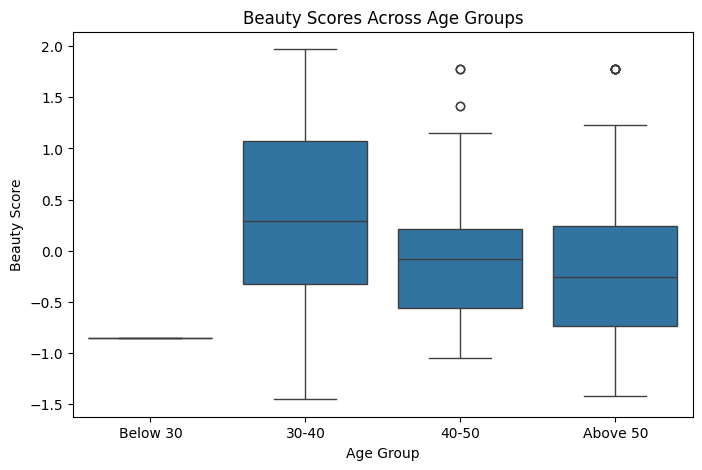

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=anova_data, x='age_group', y='beauty')
plt.title("Beauty Scores Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Beauty Score")
plt.show()

**Interpretation**

One-way ANOVA compares the mean beauty scores across the age groups. If the p-value is below 0.05, there is evidence that at least one group has a different mean beauty score.

**Q3. Chi-square test: Is there an association between tenure and gender?**

**Aim**

To determine whether tenure status and gender are statistically associated using the chi-square test of independence.

**Hypotheses**

Null hypothesis (H₀): Tenure status and gender are independent.

Alternative hypothesis (H₁): Tenure status and gender are associated.

In [9]:
# Create a contingency table
contingency_table = pd.crosstab(df['tenure'], df['gender'])

print("Contingency Table:")
print(contingency_table)

# Perform chi-square test of independence
chi2, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", degrees_of_freedom)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: There is a significant association between tenure and gender.")
else:
    print("Fail to reject H0: There is no significant association between tenure and gender.")

Contingency Table:
gender  female  male
tenure              
no          50    52
yes        145   216

Chi-square statistic: 2.20678166999886
Degrees of freedom: 1
P-value: 0.1374050603563787
Fail to reject H0: There is no significant association between tenure and gender.


**Interpretation**

The chi-square test checks whether the distribution of tenure status differs according to gender. A p-value below 0.05 suggests a statistically significant association.

**Q4. Correlation: Is teaching evaluation score correlated with beauty score?**

**Aim**

To measure the strength and direction of the linear relationship between teaching evaluation score and beauty score using Pearson correlation.

**Hypotheses**

Null hypothesis (H₀): There is no linear correlation between teaching evaluation score and beauty score in the population.

Alternative hypothesis (H₁): There is a linear correlation between teaching evaluation score and beauty score in the population.

In [10]:
# Select relevant columns and remove missing values
correlation_data = df[['eval', 'beauty']].dropna()

# Calculate Pearson correlation
correlation, p_value = stats.pearsonr(
    correlation_data['eval'],
    correlation_data['beauty']
)

print("Pearson correlation coefficient:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: There is a statistically significant linear correlation.")
else:
    print("Fail to reject H0: There is no statistically significant linear correlation.")

Pearson correlation coefficient: 0.18903909062278274
P-value: 4.247115507786e-05
Reject H0: There is a statistically significant linear correlation.


**Visualization-**

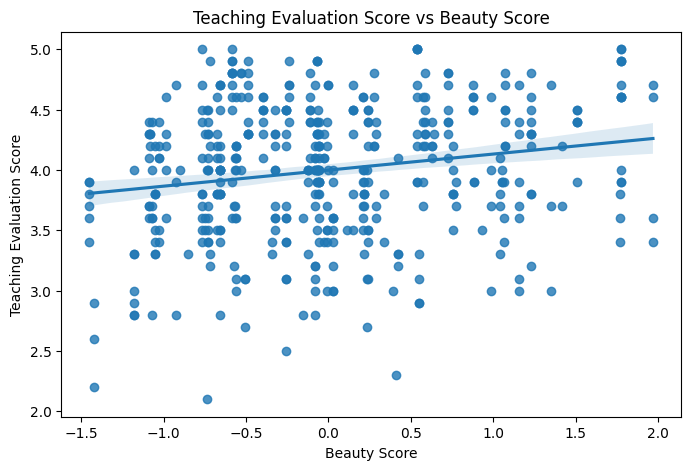

In [11]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=correlation_data,
    x='beauty',
    y='eval'
)

plt.title("Teaching Evaluation Score vs Beauty Score")
plt.xlabel("Beauty Score")
plt.ylabel("Teaching Evaluation Score")
plt.show()

**Interpretation**

The Pearson correlation coefficient ranges from −1 to +1. A positive value indicates that higher beauty scores tend to be associated with higher evaluation scores, while a negative value indicates an inverse relationship. The p-value helps determine whether the observed correlation is statistically significant.